In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import torch.optim as optim


torch.manual_seed(42)
np.random.seed(140)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
df = pd.read_csv('inital.csv')
y = df['y']
x1 = df['x1']
x2 = df['x2']
o = y == 0
plus = y == 1

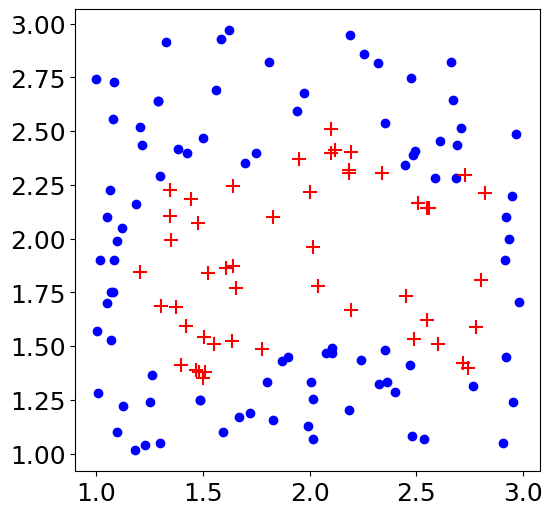

In [4]:


plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(6,6))
plt.scatter(x1[o], x2[o], marker='o', color='blue', label='y=0')
plt.scatter(x1[plus], x2[plus], marker='+', color='red', s=100, label='y=1')
# plt.xlabel('x1')
# plt.ylabel('x2')
# # plt.title('Decision Boundary')
# plt.tight_layout()
plt.savefig("data_dist.pdf", format='pdf')

In [5]:
x_lims = ax.get_xlim()

In [6]:
x_lims

(0.9029601334007787, 3.081167360786655)

A simple decision tree, non-differntiable

Feature importances: x1 = 0.4167, x2 = 0.5833


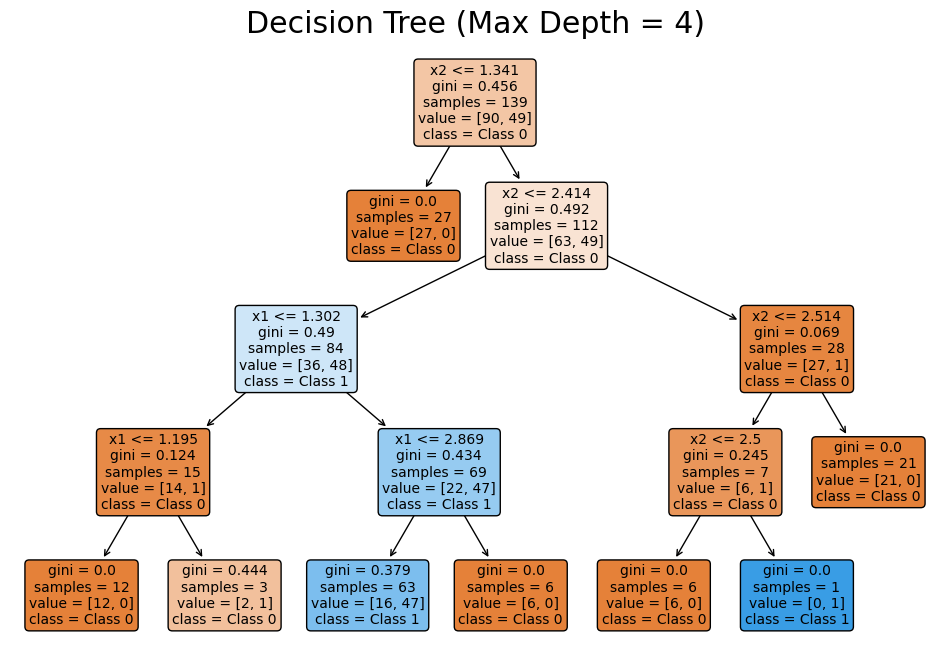

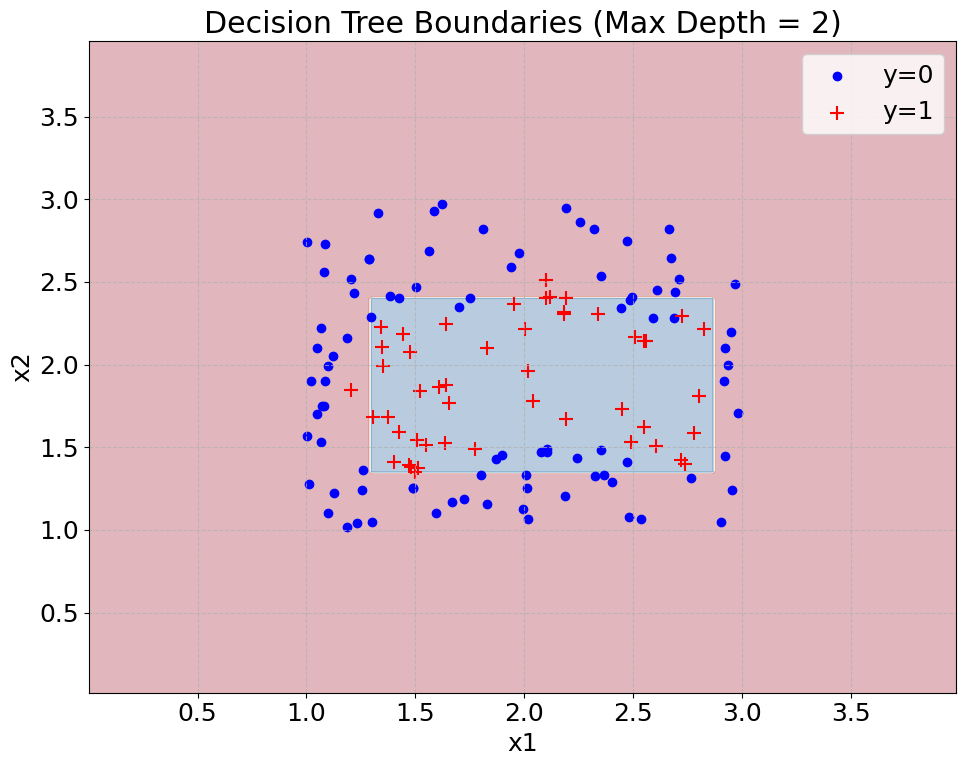

In [9]:
X = np.column_stack((x1, x2))

# Create a decision tree classifier with max depth of 2
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the classifier
clf.fit(X, y)

# Create a figure
plt.figure(figsize=(12, 8))

# Plot the decision tree
plot_tree(clf, 
          feature_names=['x1', 'x2'],
          class_names=['Class 0', 'Class 1'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree (Max Depth = 4)')

# Let's also visualize the decision boundaries in the feature space
plt.figure(figsize=(10, 8))

# Create a meshgrid to plot the decision boundaries
h = 0.02  # Step size
x1_min, x1_max = x1.min() - 1, x1.max() + 1
x2_min, x2_max = x2.min() - 1, x2.max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                       np.arange(x2_min, x2_max, h))

# Make predictions on the meshgrid
Z = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

# Plot the decision boundaries
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=plt.cm.RdBu)

# Plot the original data points
zeros = y == 0
ones = y == 1
plt.scatter(x1[zeros], x2[zeros], marker='o', color='blue', label='y=0')
plt.scatter(x1[ones], x2[ones], marker='+', color='red', s=100, label='y=1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Tree Boundaries (Max Depth = 2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show feature importances
importances = clf.feature_importances_
print(f"Feature importances: x1 = {importances[0]:.4f}, x2 = {importances[1]:.4f}")





plt.tight_layout()
plt.show()

In [10]:

class SimpleDecisionTree(nn.Module):
    def __init__(self, input_size):
        super(SimpleDecisionTree, self).__init__()
        if input_size == 2:
            self.x1_lower = nn.Parameter(torch.tensor([1.19]))
            self.x1_upper = nn.Parameter(torch.tensor([2.86]))
            self.x2_lower = nn.Parameter(torch.tensor([1.34]))
            self.x2_upper = nn.Parameter(torch.tensor([2.45]))
            self.k = nn.Parameter(torch.tensor([115.0]))
        else:
            raise ValueError(f"Input dimension != 2 not supported!")


    def forward(self, x):
        
        x1 = x[:, 0]
        x2 = x[:, 1]
        
        bound1 = torch.sigmoid(self.k *(x1 - self.x1_lower))
        bound2 = torch.sigmoid(self.k * (self.x1_upper - x1))
        bound3 = torch.sigmoid(self.k * (x2 - self.x2_lower))
        bound4 = torch.sigmoid(self.k * (self.x2_upper - x2))
        
        output = bound1 * bound2 * bound3 * bound4
        return torch.reshape(output, (-1,1))


def prepare_data(df, x_cols=['x1', 'x2'], y_col='y', test_size=0.2):
    
    X = df[x_cols].values
    y = df[y_col].values.reshape(-1, 1)
    

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test = scaler.transform(X_test)
    

    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test)
    
    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor


def train_model(model, X_train, y_train, X_test, y_test, epochs=2, lr=0.04, batch_size=None):

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Lists to store loss history
    train_losses = []
   
    

    for epoch in range(epochs):

        outputs = model(X_train)

        print(f'outputs shape:{outputs.shape}, y train:{y_train.shape}')
        train_loss = criterion(outputs, y_train)
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        

        

        train_losses.append(train_loss.item())

        
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}')
    
    return train_losses


def evaluate_model(model, X_test, y_test):
    with torch.no_grad():

        y_pred = model(X_test)
        
        # y_test = torch.reshape(y_test, (-1,))
        y_pred_binary = (y_pred > 0.5).float()
        print(f'y_pred shape: {y_pred_binary.shape}, y_test shape: {y_test.shape}')

        accuracy = (y_pred_binary == y_test).float().mean().item()
        
        print(f'Test Accuracy: {accuracy:.4f}')

        true_positives = ((y_pred_binary == 1) & (y_test == 1)).float().sum().item()
        false_positives = ((y_pred_binary == 1) & (y_test == 0)).float().sum().item()
        true_negatives = ((y_pred_binary == 0) & (y_test == 0)).float().sum().item()
        false_negatives = ((y_pred_binary == 0) & (y_test == 1)).float().sum().item()
        
        print("Confusion Matrix:")
        print(f"True Positives: {true_positives}, False Positives: {false_positives}")
        print(f"True Negatives: {true_negatives}, False Negatives: {false_negatives}")
    
    return accuracy


# Plot the loss curves
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [11]:
x_columns=['x1', 'x2']
y_column='y'
X_train, X_test, y_train, y_test = prepare_data(
    df, x_cols=x_columns, y_col=y_column, test_size=0.001
)

# # Initialize the model
# input_size = len(x_columns)
# model = SimpleDecisionTree(input_size)

# # Train the model
# train_losses = train_model(
#     model, X_train, y_train, X_test, y_test, 
#     epochs=100, lr=0.05
# )


# Plot the decision boundary (only if we have 2 features)



In [12]:
model = SimpleDecisionTree(2)
model.load_state_dict(torch.load('simpleDecisiontree.pth'))
model.eval()

SimpleDecisionTree()

In [13]:
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

x1_lower: tensor([1.1944])
x1_upper: tensor([2.8657])
x2_lower: tensor([1.4340])
x2_upper: tensor([2.3599])
k: tensor([110.1636])


In [97]:
# Visualize decision boundary
def plot_decision_boundary(model, X, y, feature_names=['x1', 'x2']):
    # Create a mesh grid to visualize the decision boundary
    x1_min, x1_max = 1.0, 3
    x2_min, x2_max = 1, 3
    h = 0.005
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    
    # Scale mesh grid points
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    scaled_grid_points = grid_points
    
    # Predict for each point in the mesh grid
    Z = model(torch.FloatTensor(scaled_grid_points))
    Z = Z.detach().numpy().reshape(xx1.shape)
    Z = (Z > 0.5).astype(int)
    # Plot decision boundary and data points
    
    plt.rcParams.update({'font.size': 18})
    plt.figure(figsize=(6, 6))
    # This functions colors the inside of the plot
    # plt.contourf(xx1, xx2, Z, alpha=0.8, cmap=plt.cm.Purples)
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='purple', linewidths=2.0)
    plt.ylim(0.9174749336465787, 3.066280477258978)
    plt.xlim(0.9029601334007787, 3.081167360786655)
    o = y == 0
    plus = y == 1

    original_data =X_train.numpy()

    #plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
    plt.scatter(original_data[o.reshape(-1,), 0], original_data[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

    # Plot points where y=1 as plus signs
    plt.scatter(original_data[plus.reshape(-1,), 0], original_data[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')
    # # Get original data (unscaled) for plotting
    # original_data = scaler.inverse_transform(X.numpy())
    # plt.scatter(original_data[:, 0], original_data[:, 1], c=y.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
    
    # plt.xlabel(feature_names[0])
    # plt.ylabel(feature_names[1])
    # # plt.title('Decision Boundary')
    # plt.tight_layout()
    plt.savefig('decisionboundary.png', dpi=300)
    plt.show()


In [98]:
X_train, X_test, y_train, y_test = prepare_data(
    df, x_cols=['x1','x2'], y_col='y', test_size=0.0001
)

y_pred shape: torch.Size([138, 1]), y_test shape: torch.Size([138, 1])
Test Accuracy: 0.8478
Confusion Matrix:
True Positives: 37.0, False Positives: 10.0
True Negatives: 80.0, False Negatives: 11.0


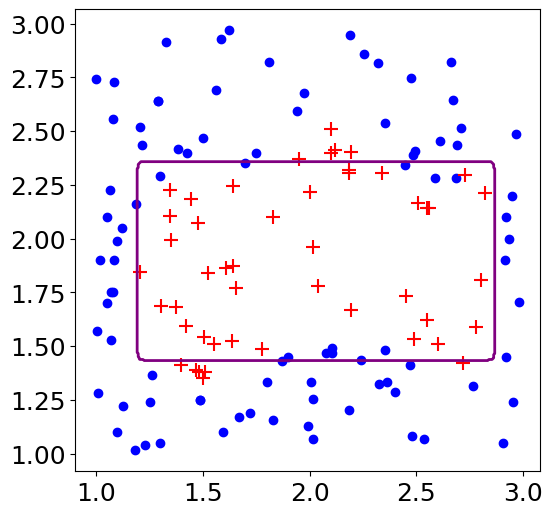


Model parameters:
x1_lower: tensor([1.1944])
x1_upper: tensor([2.8657])
x2_lower: tensor([1.4340])
x2_upper: tensor([2.3599])
k: tensor([110.1636])


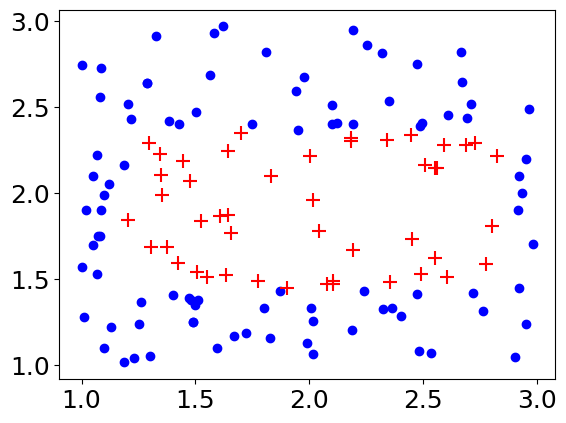

In [99]:


# Evaluate the model
evaluate_model(model, X_train, y_train)
# Get predictions

plot_decision_boundary(model, X_train, y_train, feature_names=['x1','x2'])

# Print model parameters
print("\nModel parameters:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")
X_train, X_test, y_train, y_test = prepare_data(
    df, x_cols=['x1','x2'], y_col='y', test_size=0.0001
)
y_predt = model(X_train)

# Convert predictions to binary (0 or 1)
y_pred_binary = (y_predt > 0.5).float()
o = y_pred_binary == 0
plus = y_pred_binary == 1

original_data = X_train.numpy()

#plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
plt.scatter(original_data[o.reshape(-1,), 0], original_data[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

# Plot points where y=1 as plus signs
plt.scatter(original_data[plus.reshape(-1,), 0], original_data[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')

In [31]:
# torch.save(model.state_dict(), 'simpleDecisiontree.pth')

In [57]:
torch.min(X_train[:,1])

tensor(1.0151)

In [58]:
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
result = 2.0+ x
print(result)

tensor([[3., 4.],
        [5., 6.]])


In [32]:
class InputTransform(nn.Module):
    def __init__(self, input_dim=2, neuron_n=16):
        super(InputTransform, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, neuron_n),
            nn.BatchNorm1d(neuron_n),
            nn.LeakyReLU(0.1),
            nn.Linear(neuron_n, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.net(x)
        # x = x + 2.0
        return x
    
class CombinedModel(nn.Module):
    def __init__(self, simple_model, transformer):
        super(CombinedModel, self).__init__()
        self.simple = simple_model
        self.transformer = transformer
        
        for param in self.simple.parameters():
            param.requires_grad = False
    
    
    def forward(self, x):
        change = self.transformer(x)
        new_input = x + change
        output = self.simple(new_input)
        return {
            'change' : change,
            'output' : output
        }
        
        

In [33]:
input_transformer = InputTransform(input_dim=2).to(device)
combined_model = CombinedModel(simple_model=model, transformer=input_transformer).to(device)


In [ ]:
input_transformer = InputTransform(input_dim=2).to(device)
combined_model = CombinedModel(simple_model=model, transformer=input_transformer).to(device)
combined_model.load_state_dict(torch.load('binarycombined.pth'))

In [34]:
optimizer = optim.Adam(combined_model.transformer.parameters(), lr=0.005)
classification_criterion = nn.BCELoss(reduction='sum')
mse_criterion = nn.MSELoss(reduction='sum')
train_losses = []
print("Training the combined model")
num_epochs = 10000
for epoch in range(num_epochs):
    combined_model.transformer.train()
    

    
    optimizer.zero_grad()
    
    outputs = combined_model(X_train)
    classifier_loss = classification_criterion(outputs['output'], y_train)
    loss = classifier_loss + 10 * torch.norm(outputs['change'], p=2)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss)
    if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}=class: {classifier_loss} + norm: {5 * torch.norm(outputs["change"], p=2)}')
            
            


Training the combined model
Epoch [10/10000], Train Loss: 2405.9395=class: 2303.2216796875 + norm: 51.35889434814453
Epoch [20/10000], Train Loss: 1540.2886=class: 1438.6966552734375 + norm: 50.79593276977539
Epoch [30/10000], Train Loss: 1482.1277=class: 1381.451904296875 + norm: 50.33789825439453
Epoch [40/10000], Train Loss: 1449.5009=class: 1351.2294921875 + norm: 49.135704040527344
Epoch [50/10000], Train Loss: 1431.2853=class: 1335.018310546875 + norm: 48.13350296020508
Epoch [60/10000], Train Loss: 1407.5460=class: 1312.5968017578125 + norm: 47.47462844848633
Epoch [70/10000], Train Loss: 1381.0768=class: 1287.9998779296875 + norm: 46.53842544555664
Epoch [80/10000], Train Loss: 1349.8473=class: 1258.5166015625 + norm: 45.66535949707031
Epoch [90/10000], Train Loss: 1312.0140=class: 1222.7723388671875 + norm: 44.620872497558594
Epoch [100/10000], Train Loss: 1277.7561=class: 1190.46875 + norm: 43.643707275390625
Epoch [110/10000], Train Loss: 1235.4808=class: 1150.168701171875 +

In [35]:
def evaluate_combined_model(model, X_test, y_test):
    with torch.no_grad():

        y_pred = model(X_test)
        
        # y_test = torch.reshape(y_test, (-1,))
        y_pred_binary = (y_pred['output'] > 0.5).float()
        print(f'y_pred shape: {y_pred_binary.shape}, y_test shape: {y_test.shape}')

        accuracy = (y_pred_binary == y_test).float().mean().item()
        
        print(f'Test Accuracy: {accuracy:.4f}')

        true_positives = ((y_pred_binary == 1) & (y_test == 1)).float().sum().item()
        false_positives = ((y_pred_binary == 1) & (y_test == 0)).float().sum().item()
        true_negatives = ((y_pred_binary == 0) & (y_test == 0)).float().sum().item()
        false_negatives = ((y_pred_binary == 0) & (y_test == 1)).float().sum().item()
        
        print("Confusion Matrix:")
        print(f"True Positives: {true_positives}, False Positives: {false_positives}")
        print(f"True Negatives: {true_negatives}, False Negatives: {false_negatives}")
    
    return accuracy

In [36]:
evaluate_combined_model(combined_model, X_train, y_train)

y_pred shape: torch.Size([138, 1]), y_test shape: torch.Size([138, 1])
Test Accuracy: 0.9928
Confusion Matrix:
True Positives: 47.0, False Positives: 0.0
True Negatives: 90.0, False Negatives: 1.0


0.9927536249160767

shape of y_train=torch.Size([138, 1]), shape of y_pred=torch.Size([138, 1])
Test Accuracy: 0.9928
Confusion Matrix:
True Positives: 47.0, False Positives: 0.0
True Negatives: 90.0, False Negatives: 1.0


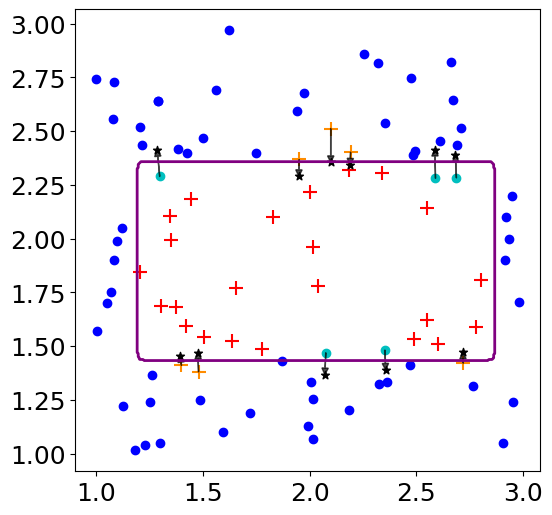

In [95]:
with torch.no_grad():

        y_pred = combined_model(X_train)
        y_pred_original = model(X_train)
        y_pred_original = (y_pred_original > 0.5).float()
        y_pred_binary = (y_pred['output'] > 0.5).float()
        points_changed = (y_pred_original != y_pred_binary)
        X_changed = X_train[points_changed.reshape(-1,),:]
        change_ = y_pred['change'][points_changed.reshape(-1,),:]
        new_x = X_changed + change_
        new_x = new_x.numpy()
        
        
        # o = y_train == 0
        # plus = y_train == 1
        print(f'shape of y_train={y_train.shape}, shape of y_pred={y_pred_original.shape}')
        X_unchanged = X_train[~points_changed.reshape(-1,),:]
        y_original_model_unchanged = y_train[~points_changed.reshape(-1,),:]
        o = y_original_model_unchanged == 0
        plus = y_original_model_unchanged == 1
        
        y_original_model_changed = y_pred_original[points_changed.reshape(-1,),:]
        y_train_changed = y_train[points_changed.reshape(-1,),:]
        o_changed = y_train_changed == 0
        plus_changed = y_train_changed == 1
        
        # Make the plot a bit less crowded:
        # randomly select 80% of unchanged points:
        
        unchanged_indices = np.random.choice(
                np.arange(len(X_unchanged)), 
                size=int(0.70 * len(X_unchanged)), 
                replace=False
        )
        X_unchanged_sample = X_unchanged[unchanged_indices]
        o_sample = o.reshape(-1)[unchanged_indices]
        plus_sample = plus.reshape(-1)[unchanged_indices]
        
        
        # Randomly select 80% of changed points
        changed_indices = np.random.choice(
                np.arange(len(X_changed)), 
                size=int(0.5 * len(X_changed)), 
                replace=False
        )
        
        
        X_changed_sample = X_changed[changed_indices]
        o_changed_sample = o_changed.reshape(-1)[changed_indices]
        plus_changed_sample = plus_changed.reshape(-1)[changed_indices]
        new_x_sample = new_x[changed_indices]
        
        
        
        
        # plot_decision_boundary(model, X_train, y_train, scaler, feature_names=x_columns)
        
        x1_min, x1_max = 1.0, 3
        x2_min, x2_max = 1, 3
        h = 0.005
        xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
        
        # Scale mesh grid points
        grid_points = np.c_[xx1.ravel(), xx2.ravel()]
        # scaled_grid_points = scaler.transform(grid_points)
        
        # Predict for each point in the mesh grid
        Z = model(torch.FloatTensor(grid_points))
        Z = Z.detach().numpy().reshape(xx1.shape)
        Z = (Z > 0.5).astype(int)
        # Plot decision boundary and data points
        
        plt.rcParams.update({'font.size': 18})
        plt.figure(figsize=(6, 6))
        # This functions colors the inside of the plot
        # plt.contourf(xx1, xx2, Z, alpha=0.8, cmap=plt.cm.Purples)
        plt.contour(xx1, xx2, Z, levels=[0.5], colors='purple', linewidths=2.0)
        #plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
        # plt.figure(figsize=((6,6)))
        plt.ylim(0.9174749336465787, 3.066280477258978)
        plt.xlim(0.9029601334007787, 3.081167360786655)
        # plt.scatter(X_unchanged[o.reshape(-1,), 0], X_unchanged[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

        # # Plot points where y=1 as plus signs
        # plt.scatter(X_unchanged[plus.reshape(-1,), 0], X_unchanged[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')
        # #plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
        # # plt.scatter(X_changed[:, 0], X_changed[:, 1], marker='.', color='green', label='original to be changed')
        # plt.scatter(X_changed[o_changed.reshape(-1,), 0], X_changed[o_changed.reshape(-1,), 1], marker='o', color='c', label='y=0')

        # # Plot points where y=1 as plus signs
        # plt.scatter(X_changed[plus_changed.reshape(-1,), 0], X_changed[plus_changed.reshape(-1,), 1], marker='+', color='darkorange', s=100, label='y=1')
        # # Plot points where y=1 as plus signs
        # plt.scatter(new_x[:, 0], new_x[:, 1], marker='*', color='darkred', s=35, label='changed data')
        # # plt.legend()
        # for i in range(len(X_changed)):
        #         plt.arrow(X_changed[i, 0], X_changed[i, 1], 
        #                 new_x[i, 0] - X_changed[i, 0], 
        #                 new_x[i, 1] - X_changed[i, 1],
        #                 head_width=0.02, head_length=0.03, 
        #                 fc='green', ec='green', 
        #                 length_includes_head=True,
        #                 alpha=0.7)
        # plt.savefig('combined.png', dpi=300)
        
        
        # Plot sampled unchanged points
        plt.scatter(X_unchanged_sample[o_sample, 0], X_unchanged_sample[o_sample, 1], marker='o', color='blue', label='y=0')
        plt.scatter(X_unchanged_sample[plus_sample, 0], X_unchanged_sample[plus_sample, 1], marker='+', color='red', s=100, label='y=1')

        # Plot sampled changed points
        plt.scatter(X_changed_sample[o_changed_sample, 0], X_changed_sample[o_changed_sample, 1], marker='o', color='c', label='y=0')
        plt.scatter(X_changed_sample[plus_changed_sample, 0], X_changed_sample[plus_changed_sample, 1], marker='+', color='darkorange', s=100, label='y=1')
        plt.scatter(new_x_sample[:, 0], new_x_sample[:, 1], marker='*', color='black', s=35, label='changed data')

        # Add arrows showing the movement from original points to new points
        for i in range(len(X_changed_sample)):
                plt.arrow(X_changed_sample[i, 0], X_changed_sample[i, 1], 
                        new_x_sample[i, 0] - X_changed_sample[i, 0], 
                        new_x_sample[i, 1] - X_changed_sample[i, 1],
                        head_width=0.03, head_length=0.03, 
                        fc='black', ec='black', 
                        length_includes_head=True,
                        alpha=0.7)
        plt.savefig('combined.png', dpi=300)
        accuracy = (y_pred_binary == y_train).float().mean().item()
        
        print(f'Test Accuracy: {accuracy:.4f}')

        true_positives = ((y_pred_binary == 1) & (y_train == 1)).float().sum().item()
        false_positives = ((y_pred_binary == 1) & (y_train == 0)).float().sum().item()
        true_negatives = ((y_pred_binary == 0) & (y_train == 0)).float().sum().item()
        false_negatives = ((y_pred_binary == 0) & (y_train == 1)).float().sum().item()
        
        print("Confusion Matrix:")
        print(f"True Positives: {true_positives}, False Positives: {false_positives}")
        print(f"True Negatives: {true_negatives}, False Negatives: {false_negatives}")